In [2]:
%load_ext autoreload
%autoreload 2
from neuropy.analyses import correlations 
import numpy as np
import neuropy.analyses.ms_connectivity as msconn
import seaborn as sns
import matplotlib.pyplot as plt
import time
import subjects
skips = {} # epoch='post'
skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','pyr'))]=np.array([41,98])
skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','inter'))]=np.array([44,21])
skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='I',conn_type=('inter','inter'))]=np.array([[129,125],[21,0],[139,66]])

Error importing CuPy
Error importing CuPy


/Users/selinl/miniforge3/envs/NeuroPy2/lib/python3.11/site-packages/xarray/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
sess = subjects.nsd.allsess[5]
use_acceleration = False

In [ ]:
cconf=msconn.CCGConfig(use_acceleration=use_acceleration,normalize=msconn.NormalizeBy.BOTH_FRATE)
ndconf=msconn.NeuronsDatasetConfig(seg_stride=60*60*0.5, seg_len=60*60*5, epochs=['post'], sleep_labels=None,recinfo=sess.recinfo)
nd=msconn.NeuronsDataset(sess,ndconf)

In [ ]:
# get maximum number of significant pairs by using the whole dataset
cd=msconn.CCGDataset(nd,cconf)
cd.get_ccg()

EranConv significant pairs
running eranconv (1st pass)
running spike correlations
spike correlation done
eranconv (1st pass) done
=======RatU_Day2NSD=======
Segment(s) are 9.02h each and contain ['9.02'] hours of actual sleep pyr=174 inter=14 
SLEEP0: E/I pairs 173 / 186 | pyr-pyr/E 07 | pyr-inter/E 97 | inter-inter/I 50 | inter-pyr/I 23 | 
SLEEP1: E/I pairs 174 / 174 | pyr-pyr/E 07 | pyr-inter/E 103 | inter-inter/I 48 | inter-pyr/I 22 | 
SLEEP2: E/I pairs 174 / 160 | pyr-pyr/E 07 | pyr-inter/E 105 | inter-inter/I 44 | inter-pyr/I 22 | 
SLEEP3: E/I pairs 178 / 168 | pyr-pyr/E 06 | pyr-inter/E 109 | inter-inter/I 44 | inter-pyr/I 25 | 
SLEEP4: E/I pairs 176 / 182 | pyr-pyr/E 04 | pyr-inter/E 108 | inter-inter/I 44 | inter-pyr/I 32 | 
SLEEP5: E/I pairs 188 / 184 | pyr-pyr/E 04 | pyr-inter/E 116 | inter-inter/I 46 | inter-pyr/I 29 | 
SLEEP6: E/I pairs 196 / 184 | pyr-pyr/E 04 | pyr-inter/E 122 | inter-inter/I 46 | inter-pyr/I 32 | 
SLEEP7: E/I pairs 203 / 180 | pyr-pyr/E 05 | pyr-inter/E 

In [ ]:
cd.get_connection_strengths(method="eran_conv")
cd.get_connectivity()

In [ ]:
cd.reCCG_pair_inds()

running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-pyr
running spike correlations
spike correlation done
done
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-inter
running spike correlations
spike correlation done
done
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-inter
running spike correlations
spike correlation done
done
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-pyr
running spike correlations
spike correlation done
done
recomputed CCG for pairs that had been significant in any segment


In [8]:
cd.normalize()
cd.set_connection_strengths()
cd.set_connectivity()

In [9]:
cd.example('connectivity')

sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-pyr
[ 26 157]      	In segments [0 1 2 3]           	strengths: [45.38010992 64.28801029 69.51816296 50.73281608 16.45107549  0.
  0.          0.          0.        ]
[ 28 157]      	In segments [0 1 2]             	strengths: [21.68219932 30.2403825  36.68810061 31.68867897 29.33542458  0.
  0.          0.          0.        ]
[123  31]      	In segments [0]                 	strengths: [107.80054779  17.29998032   6.97853638   7.66706712   4.40659173
   0.           5.04827259   2.52894897  12.11477538]
[147   7]      	In segments [0 1 2 3 4 5 6 7]   	strengths: [-52.00940409 -48.69719407 -53.65664333 -56.31137329 -59.65748249
 -57.92114668 -53.28564234 -48.65181354 -54.75188584]
[160  46]      	In segments [0 1 2 3 4 5 6 7 8] 	strengths: [28.38978187 30.95492321 36.1976832  34.54915609 35.7796622  34.14802943
 35.07297418 30.88268699 30.0155388 ]
[165  46]      	In segments [0 1 2 3 4 5 6 7 8] 	strengths: [37.32357826 40.25599983 45.35676079

In [10]:
skips = {} # epoch='post'
# skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','pyr'))]=np.array([[109, 182]])
# skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','inter'))]=np.array([[3, 129]])
# skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='I',conn_type=('inter','pyr'))]=np.array([[ 21,  59]])


sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-pyr None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


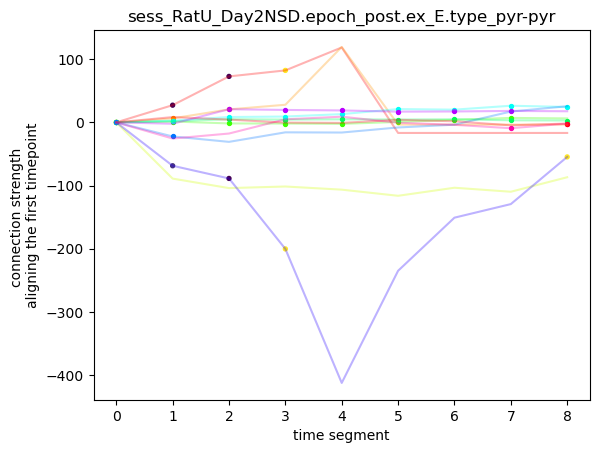

pvals [0.19983367 0.51902875 0.50541171 0.60373754 0.22343636 0.22344396
 0.26844918 0.45231644] threshold 0.00625 

mean values [-1.37273583 -0.66836624 -0.69079619 -0.53590696 -1.29796874 -1.29794574
 -1.17177329 -0.78202936] 

sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-inter None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


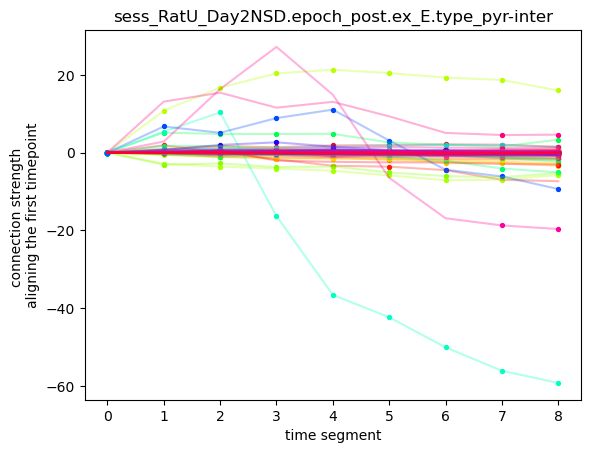

pvals [0.0134156  0.01523078 0.20510683 0.71586865 0.44178742 0.17455304
 0.12546942 0.09557707] threshold 0.00625 

mean values [ 2.50103529  2.45392286  1.27244933  0.36464715 -0.771145   -1.36393407
 -1.54047988 -1.6768371 ] 

sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-inter None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


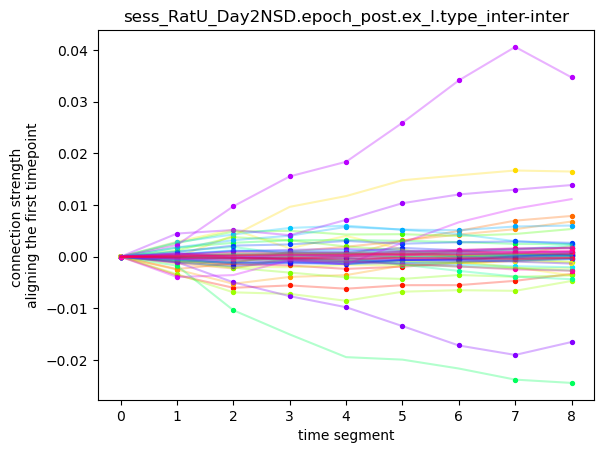

pvals [0.79454491 0.85242744 0.76961641 0.82238511 0.51455873 0.46627488
 0.41766603 0.31597848] threshold 0.00625 

mean values [-0.261681   -0.18689914  0.29432651  0.22555303  0.65600071  0.73365516
  0.81662477  1.01198114] 

sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-pyr None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


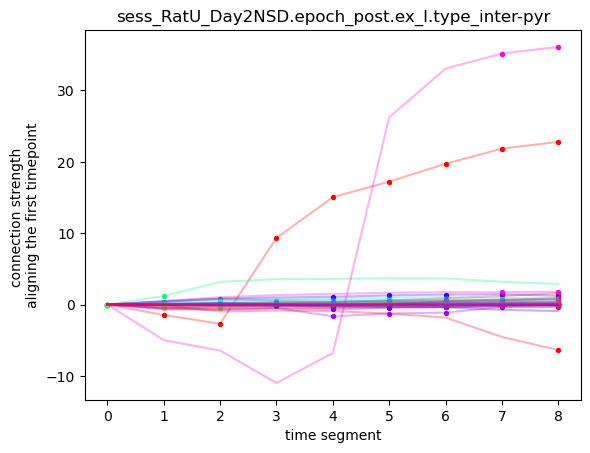

pvals [0.22416927 0.42313437 0.78503207 0.48141797 0.11134879 0.11578315
 0.12569913 0.13162656] threshold 0.00625 

mean values [-1.23210932 -0.80820206  0.27436563  0.70978857  1.62334993  1.60298573
  1.55964031  1.53503014] 



In [11]:
cd.plot_connection_strengths(show_legend=False,
                                norm_by_total_strength=False,
                                zero_first_timepoint=True,
                                norm_by_n_sess=False,
                                save=False,
                                root="/home/selinali/Documents/NeuroPy/images/conn_strength_1218_RefRateNorm/1-zero_first_timepoint",
                                skips=skips,
                                debug=False)

# individual plots

In [10]:
_=cd.save_plots(root="~/Documents/NeuroPy/images/ccg_plots_0101_2",conn_types=[('pyr','inter')])

[Key(session='RatU_Day2NSD', epoch='post', ref_ind=None, target_ind=None, segment=None, excitability='E', conn_type=('pyr', 'inter'))]
Saving plots under ~/Documents/NeuroPy/images/ccg_plots_0101_2
ccg RatU_Day2NSD ('pyr', 'inter')
0 [ 1 70]
1 [  1 119]
2 [ 2 21]
3 [  2 125]
4 [  3 129]
5 [  4 129]
6 [  4 125]
7 [  5 156]
8 [ 9 42]
9 [10 42]
10 [11 42]
11 [ 13 102]
12 [14 21]
13 [ 16 125]
14 [ 18 125]
15 [ 18 102]
16 [ 18 129]
17 [ 18 170]
18 [ 19 129]
19 [23 42]
20 [ 26 156]
21 [26 21]
22 [26  0]
23 [26 70]
24 [ 26 170]
25 [ 26 125]
26 [ 26 129]
27 [ 27 119]
28 [ 27 129]
29 [ 28 156]
30 [28 21]
31 [30 21]
32 [ 32 119]
33 [ 32 129]
34 [ 35 170]
35 [ 36 170]
36 [ 37 125]
37 [37  6]
38 [38 42]
39 [ 41 139]
40 [44 21]
41 [45 21]
42 [ 45 119]
43 [ 45 129]
44 [ 45 170]
45 [ 47 129]
46 [ 47 170]
47 [51 42]
48 [52 42]
49 [ 53 139]
50 [53 42]
51 [57 70]
52 [ 57 129]
53 [ 57 125]
54 [ 57 119]
55 [ 58 170]
56 [58 21]
57 [59 21]
58 [ 60 119]
59 [60 70]
60 [ 60 129]
61 [66 42]
62 [71 21]
63 [72 21